In [68]:
!pip install pandas scikit-learn matplotlib seaborn gradio

In [69]:
from google.colab import files
files.upload()

Saving blood type prediction dataset.csv to blood type prediction dataset (3).csv


{'blood type prediction dataset (3).csv': b'Age,Gender,Hemoglobin,RBC_Count,WBC_Count,Platelets,Cholesterol,Blood_Pressure,Sugar_Level,BMI,Blood_Group\r22,1,13.5,5.1,7200,250000,190,120,95,22.5,O+\r25,0,12.8,4.8,6800,210000,180,110,90,21.2,A+\r30,1,14.2,5.5,8000,300000,210,130,110,25.1,B+\r28,0,11.9,4.2,7500,280000,200,115,100,23.4,AB+\r35,1,15.1,5.9,9000,320000,220,135,120,27.5,O-\r40,0,13,4.9,6700,230000,185,118,92,22.1,A-\r27,1,14.5,5.3,8200,290000,205,125,105,24.3,B-\r32,0,12.2,4.4,7100,260000,195,117,98,23,AB-\r45,1,16,6.2,9500,350000,230,140,130,28.2,O+\r29,0,13.3,4.7,6900,240000,175,112,94,21.8,A+\r33,1,14.7,5.4,8700,310000,215,128,115,26,B+\r26,0,12.5,4.5,7600,270000,198,116,99,23.5,AB+\r38,1,15.3,5.8,9100,330000,225,138,125,27.9,O-\r41,0,13.1,4.6,6800,220000,182,113,93,22.3,A-\r36,1,14.9,5.6,8800,300000,212,130,118,26.8,B-\r31,0,12.7,4.3,7000,260000,190,115,97,22.9,AB-\r24,1,13.8,5,7400,255000,200,122,102,23.8,O+\r37,0,12.9,4.6,6900,235000,185,118,95,22,A+\r34,1,14.4,5.3,8600,

Load Dataset

In [71]:
import pandas as pd

data = pd.read_csv("blood type prediction dataset.csv")
data.head()

,Age,Gender,Hemoglobin,RBC_Count,WBC_Count,Platelets,Cholesterol,Blood_Pressure,Sugar_Level,BMI,Blood_Group
0,22,1,13.5,5.1,7200,250000,190,120,95,22.5,O+
1,25,0,12.8,4.8,6800,210000,180,110,90,21.2,A+
2,30,1,14.2,5.5,8000,300000,210,130,110,25.1,B+
3,28,0,11.9,4.2,7500,280000,200,115,100,23.4,AB+
4,35,1,15.1,5.9,9000,320000,220,135,120,27.5,O-


Dataset Info

In [72]:
print("Shape:", data.shape)
print("\nColumns:", data.columns)
print("\nInfo:")
data.info()

Shape: (98, 11)

Columns: Index(['Age', 'Gender', 'Hemoglobin', 'RBC_Count', 'WBC_Count', 'Platelets',
       'Cholesterol', 'Blood_Pressure', 'Sugar_Level', 'BMI', 'Blood_Group'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             98 non-null     int64  
 1   Gender          98 non-null     int64  
 2   Hemoglobin      98 non-null     float64
 3   RBC_Count       98 non-null     float64
 4   WBC_Count       98 non-null     int64  
 5   Platelets       98 non-null     int64  
 6   Cholesterol     98 non-null     int64  
 7   Blood_Pressure  98 non-null     int64  
 8   Sugar_Level     98 non-null     int64  
 9   BMI             98 non-null     float64
 10  Blood_Group     98 non-null     object 
dtypes: float64(3), int64(7), object(1)
memory usage: 8.6+ KB


Distribution Graph

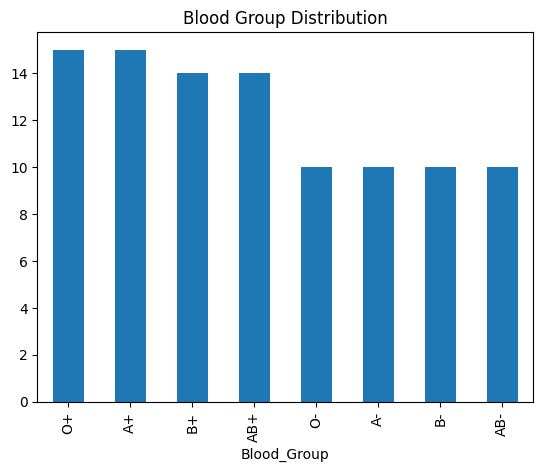

In [73]:
import matplotlib.pyplot as plt

data["Blood_Group"].value_counts().plot(kind='bar')
plt.title("Blood Group Distribution")
plt.show()

Pie Chart

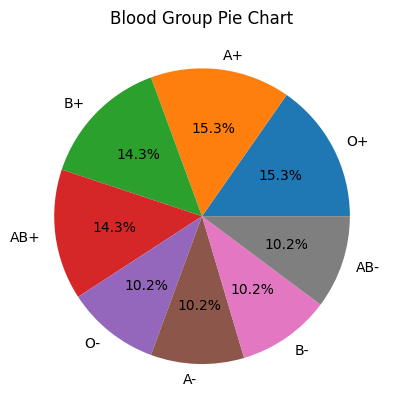

In [74]:
data["Blood_Group"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Blood Group Pie Chart")
plt.ylabel("")
plt.show()

Frequency Graph

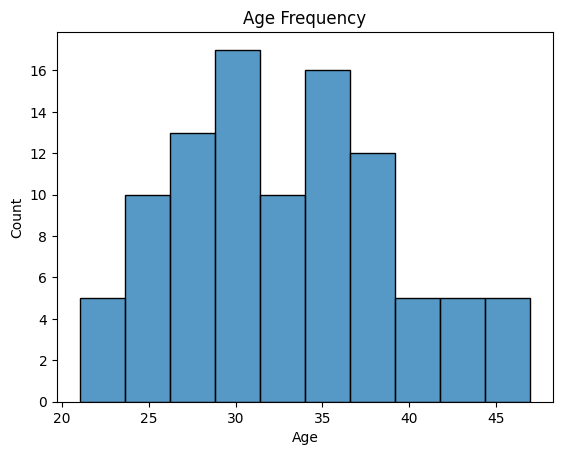

In [75]:
import seaborn as sns

sns.histplot(data["Age"], bins=10)
plt.title("Age Frequency")
plt.show()

Preprocessing

In [85]:
for col in data.columns:
    if data[col].dtype != "object":
        data[col].fillna(data[col].mean(), inplace=True)

# The 'Gender' column is already in numeric format (0 or 1) in this dataset,
# so no mapping from 'Male'/'Female' strings is needed. Removing the incorrect mapping.

# Define features and target
X = data.drop("Blood_Group", axis=1)
y = data["Blood_Group"]

print("✅ Preprocessing Done")

✅ Preprocessing Done


/tmp/ipykernel_2781/2766407815.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


Train Models

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Accuracy Graph

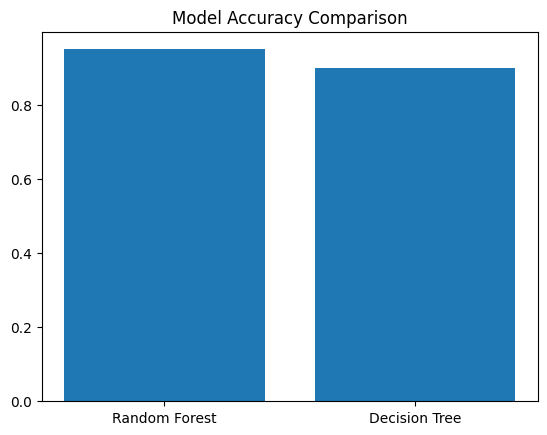

In [87]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, rf.predict(X_test))
dt_acc = accuracy_score(y_test, dt.predict(X_test))

models = ["Random Forest", "Decision Tree"]
scores = [rf_acc, dt_acc]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.show()

Confusion Matrix

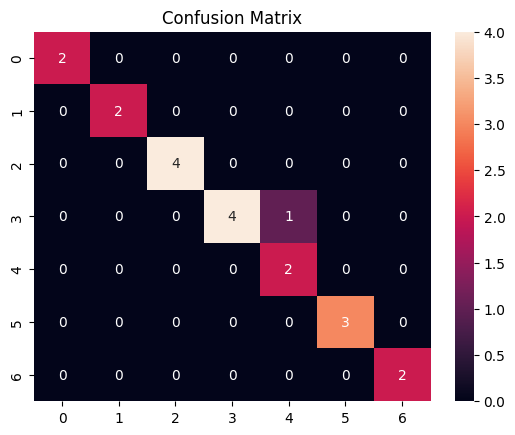

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

Feature Importance

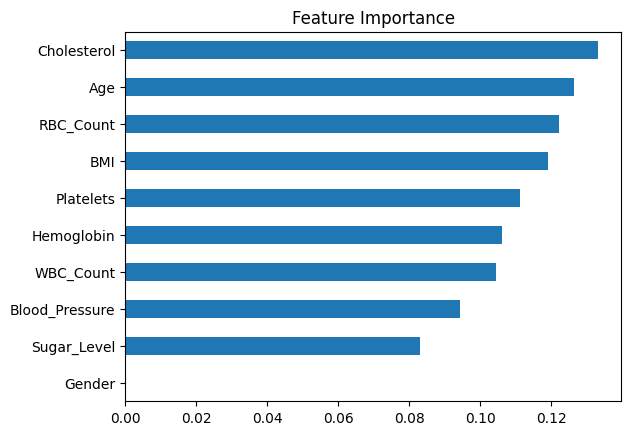

In [89]:
feat = pd.Series(rf.feature_importances_, index=X.columns)

feat.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Prediction Function

In [90]:
def predict(data_input):
    return rf.predict([data_input])[0]

In [91]:
import gradio as gr

def predict_ui(age, gender, hb, rbc, wbc, platelets, chol, bp, sugar, bmi):
    g = 1 if gender == "Male" else 0
    user = [[age,g,hb,rbc,wbc,platelets,chol,bp,sugar,bmi]]
    result = rf.predict(user)[0]
    return result

ui = gr.Interface(
    fn=predict_ui,
    inputs=[
        gr.Slider(18,60,label="Age"),
        gr.Radio(["Male","Female"], label="Gender"),
        gr.Slider(10,18,label="Hemoglobin"),
        gr.Slider(3.5,6.5,label="RBC"),
        gr.Slider(4000,11000,label="WBC"),
        gr.Slider(150000,450000,label="Platelets"),
        gr.Slider(150,300,label="Cholesterol"),
        gr.Slider(80,140,label="BP"),
        gr.Slider(70,180,label="Sugar"),
        gr.Slider(18,35,label="BMI")
    ],
    outputs="text",
    title="💉 Health Prediction System"
)

ui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6d7b86bcb74d21c0c9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Enhanced Gradio Interface with `gr.Blocks`

I'll now create a more interactive and visually appealing UI using `gr.Blocks`. This allows for custom layouts, better organization of inputs and outputs, and a more dynamic user experience. The previous `gr.Interface` will be replaced.

In [94]:
import gradio as gr
import numpy as np

def predict_blood_group(age, gender, hemoglobin, rbc_count, wbc_count, platelets, cholesterol, blood_pressure, sugar_level, bmi):
    """
    Predicts blood group based on user inputs using the trained Random Forest model.
    Also returns confidence and compatibility information.
    """
    # Convert gender to numerical (0 for Female, 1 for Male)
    g = 1 if gender == "Male" else 0

    # Prepare input features for the model
    user_input = np.array([[age, g, hemoglobin, rbc_count, wbc_count, platelets,
                            cholesterol, blood_pressure, sugar_level, bmi]])

    try:
        # Make prediction and get probabilities
        predicted_blood_group = rf.predict(user_input)[0]
        prediction_proba = rf.predict_proba(user_input)
        confidence = np.max(prediction_proba) * 100

        # Define compatibility information
        compatibility_map = {
            "O-": "Universal Donor",
            "O+": "O+, A+, B+, AB+",
            "A-": "A-, A+, AB-, AB+",
            "A+": "A+, AB+",
            "B-": "B-, B+, AB-, AB+",
            "B+": "B+, AB+",
            "AB-": "AB-, AB+",
            "AB+": "Universal Receiver"
        }
        compatibility_info = compatibility_map.get(predicted_blood_group, "Unknown compatibility")

        return (
            f"<h3 style='color:#28a745;'>Predicted Blood Group: {predicted_blood_group}</h3>",
            f"<p>Confidence: <b>{confidence:.2f}%</b></p>",
            f"<p>Compatibility: <b>{compatibility_info}</b></p>"
        )

    except Exception as e:
        return (
            f"<h3 style='color:red;'>Error during prediction:</h3>",
            f"<p style='color:red;'>{str(e)}</p>",
            ""
        )

# Create Gradio Blocks interface
with gr.Blocks(title="Blood Group Prediction System") as demo:
    gr.Markdown(
        """
        <h1 style='text-align: center; color: #007bff;'>💉 Blood Group Prediction System</h1>
        <p style='text-align: center; color: #6c757d;'>Enter the patient's health parameters to predict their blood group and compatibility.</p>
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("## Patient Information")
            age = gr.Slider(minimum=18, maximum=60, value=25, label="Age")
            gender = gr.Radio(["Male", "Female"], value="Male", label="Gender")
            hemoglobin = gr.Slider(minimum=10.0, maximum=18.0, value=13.5, label="Hemoglobin (g/dL)")
            rbc_count = gr.Slider(minimum=3.5, maximum=6.5, value=5.0, label="RBC Count (million/uL)")
            wbc_count = gr.Slider(minimum=4000, maximum=11000, value=7000, label="WBC Count (cells/uL)")

        with gr.Column():
            gr.Markdown("## Health Metrics")
            platelets = gr.Slider(minimum=150000, maximum=450000, value=250000, label="Platelets (cells/uL)")
            cholesterol = gr.Slider(minimum=150, maximum=300, value=200, label="Cholesterol (mg/dL)")
            blood_pressure = gr.Slider(minimum=80, maximum=140, value=120, label="Blood Pressure (mmHg)")
            sugar_level = gr.Slider(minimum=70, maximum=180, value=100, label="Sugar Level (mg/dL)")
            bmi = gr.Slider(minimum=18.0, maximum=35.0, value=22.0, label="BMI")

    predict_btn = gr.Button("🔮 Predict Blood Group", variant="primary")

    gr.Markdown("## Prediction Results")
    output_blood_group = gr.HTML(label="Predicted Blood Group")
    output_confidence = gr.HTML(label="Confidence")
    output_compatibility = gr.HTML(label="Compatibility")

    # Connect button click to prediction function
    predict_btn.click(
        predict_blood_group,
        inputs=[
            age, gender, hemoglobin, rbc_count, wbc_count, platelets,
            cholesterol, blood_pressure, sugar_level, bmi
        ],
        outputs=[output_blood_group, output_confidence, output_compatibility]
    )

# Launch the Gradio app
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cb6c8e79c086029a43.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7fb591e9083ef8e57e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
